In [64]:
# import modules
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

In [65]:
# functions
def create_grid(rows, cols, seed=None):
    """
    Build the table and generated colors.

    Parameters:
        rows: int, number of rows 
        cols: int, number of columns
        seed: int or None, pseudo-random seed

    Return:
        xs: array, x coordinates
        ys: array, y coordinate
        colors: array, RGB colors of each sample
    """
    y, x = np.mgrid[0:rows, 0:cols]
    xs = x.ravel()
    ys = y.ravel()
    rng = np.random.default_rng(seed)
    colors = rng.random((rows * cols, 3))
    return xs, ys, colors

def plot_sampling(xs, ys, colors, selected_idx, rows, cols, save_path, highlight_rows=None, arrows=None):
    """
    Plot sampling results with highlighted points, arrows, and highlighted rows.

    Parameters:
        xs, ys: coordinates of all points
        colors: RGB colors for all points
        selected_idx: indices of sampled points
        rows, cols: grid dimensions
        save_path: path to save the figure
        highlight_rows: list of row indices to highlight
        arrows: list of (start_idx, end_idx) tuples to draw arrows
    """
    fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
    ax.scatter(xs, ys, s=60, color=colors)

    for i in selected_idx:
        circ = Circle((xs[i], ys[i]), radius=0.35, fill=False, linewidth=1.5, color="red")
        ax.add_patch(circ)

    if highlight_rows is not None:
        for row in highlight_rows:
            idx_row = np.where(ys == row)[0]
            min_x, max_x = xs[idx_row].min(), xs[idx_row].max()
            min_y, max_y = row - 0.5, row + 0.5
            rect = plt.Rectangle((min_x - 0.5, min_y),
                                 (max_x - min_x + 1), 
                                 1,
                                 fill=False, 
                                 edgecolor="blue", 
                                 linewidth=2
                                 )
            ax.add_patch(rect)

    if arrows is not None:
        for start_idx, end_idx in arrows:
            arrow = FancyArrowPatch((xs[start_idx], ys[start_idx]),
                                    (xs[end_idx], ys[end_idx]),
                                    arrowstyle="->", 
                                    color="black", 
                                    mutation_scale=10, 
                                    lw=1.5, 
                                    transform=ax.transData
                                    )
            ax.add_patch(arrow)

    ax.invert_yaxis()
    ax.set_xticks(range(cols))
    ax.set_yticks(range(rows))
    ax.grid(True, which="both", linestyle=":")
    ax.set_xlim(-0.75, cols - 0.25)
    ax.set_ylim(-0.75, rows - 0.25)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()

In [66]:
# configs
seed = 123
rows, cols = 6, 10
xs, ys, colors = create_grid(rows, cols, seed=seed)

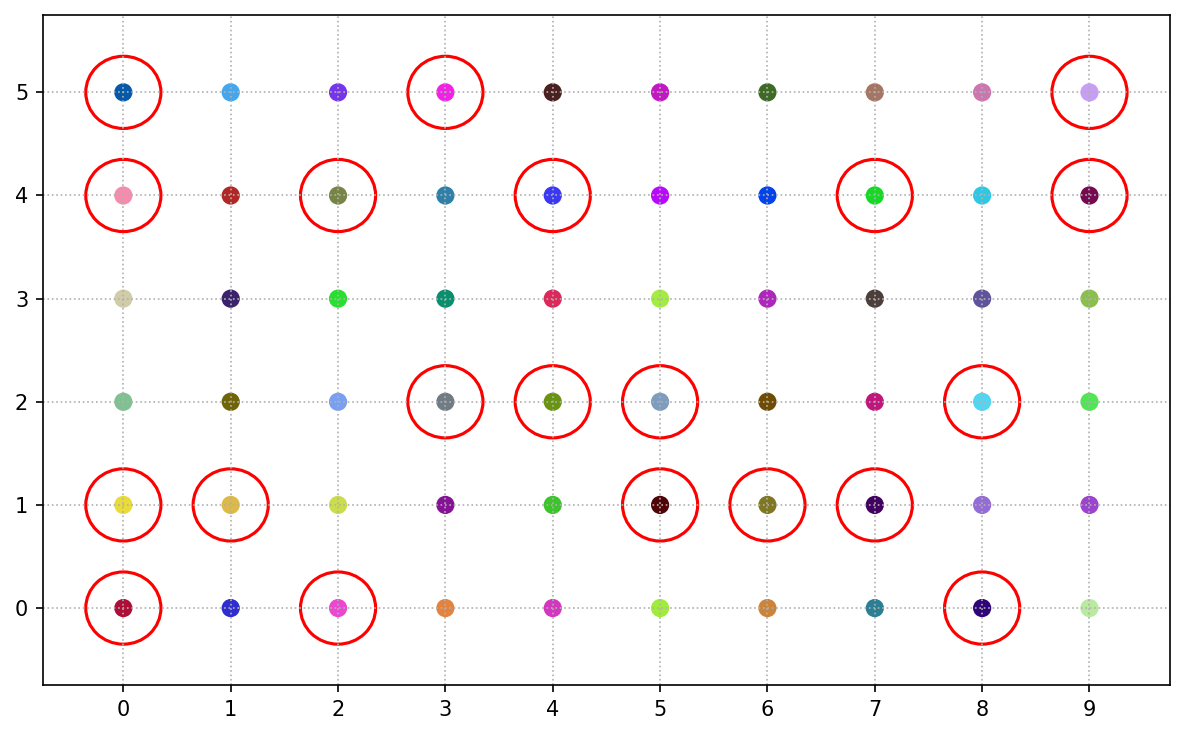

In [67]:
# sample random sampling
def simple_random_sampling(xs, ys, colors, rows, cols, k, seed=None):
    total = len(xs)
    rng = np.random.default_rng(seed)
    idx = rng.choice(total, size=k, replace=False)
    plot_sampling(xs, ys, colors, idx, rows, cols, "sample_random_sampling.webp")

simple_random_sampling(xs, ys, colors, rows, cols, k=20, seed=seed)

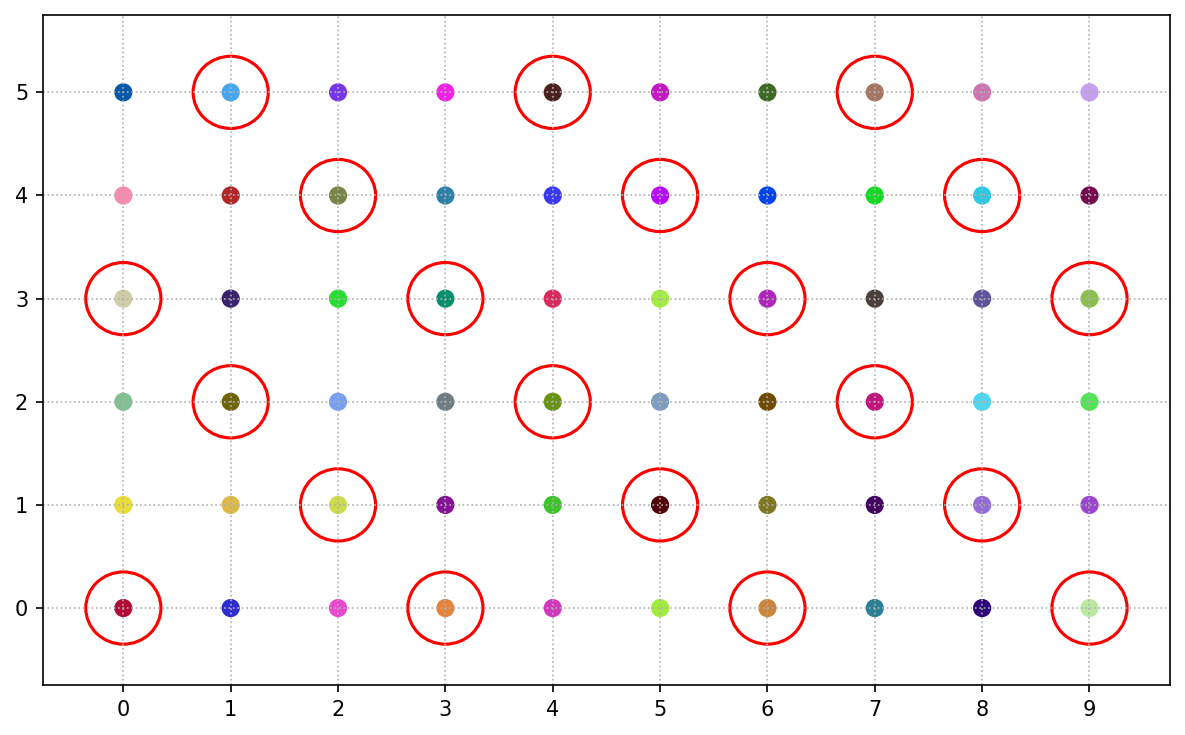

In [68]:
# systematic sampling
def systematic_sampling(xs, ys, colors, rows, cols, k, seed=None):
    total = len(xs)
    rng = np.random.default_rng(seed)
    step = total // k
    start = rng.integers(0, step)
    idx = np.arange(start, start + step * k, step) % total
    plot_sampling(xs, ys, colors, idx, rows, cols, "systematic_sampling.webp")

systematic_sampling(xs, ys, colors, rows, cols, k=20, seed=seed)

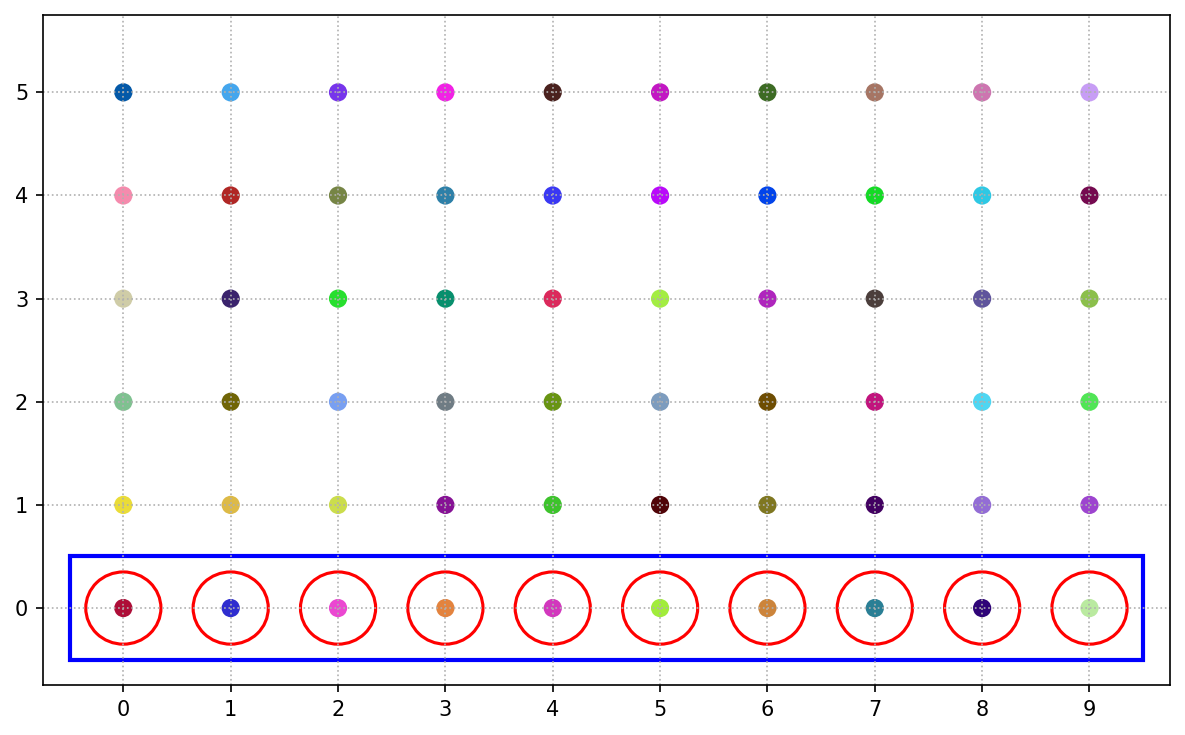

In [69]:
# one stage cluster sampling
def one_stage_cluster_sampling(xs, ys, colors, rows, cols, seed=None):
    rng = np.random.default_rng(seed)
    chosen_row = rng.integers(0, rows)
    idx_row = np.where(ys == chosen_row)[0]
    plot_sampling(xs, ys, colors, idx_row, rows, cols, "one_stage_cluster_sampling.webp", highlight_rows=[chosen_row])

one_stage_cluster_sampling(xs, ys, colors, rows, cols, seed=seed)

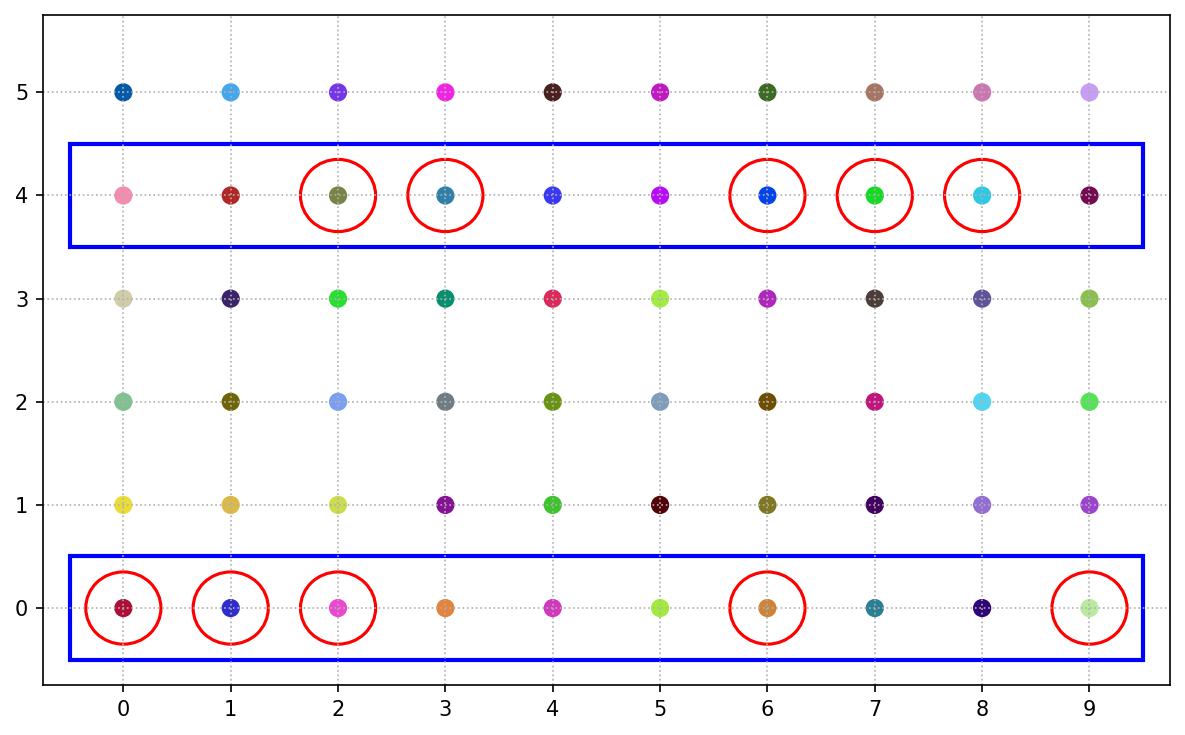

In [70]:
# two stage cluster sampling
def two_stage_cluster_sampling(xs, ys, colors, rows, cols, cluster_size, n_clusters=2, seed=None):
    rng = np.random.default_rng(seed)
    chosen_rows = rng.choice(rows, size=min(n_clusters, rows), replace=False)
    
    all_chosen_idx = []
    for row in chosen_rows:
        idx_row = np.where(ys == row)[0]
        chosen_idx = rng.choice(idx_row, size=min(cluster_size, len(idx_row)), replace=False)
        all_chosen_idx.extend(chosen_idx)
    
    plot_sampling(xs, ys, colors, all_chosen_idx, rows, cols, "two_stage_cluster_sampling.webp", highlight_rows=chosen_rows)

two_stage_cluster_sampling(xs, ys, colors, rows, cols, cluster_size=5, n_clusters=2, seed=seed)

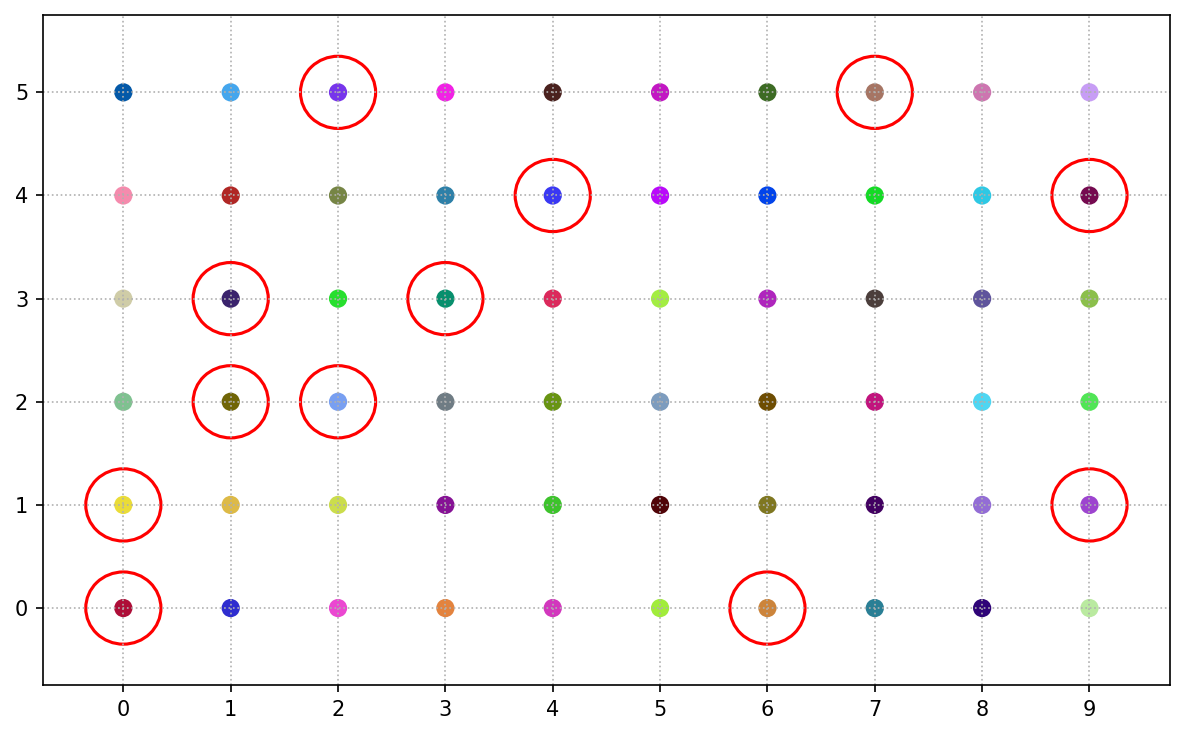

In [71]:
# stratified sampling
def stratified_sampling(xs, ys, colors, rows, cols, per_stratum, seed=None):
    rng = np.random.default_rng(seed)
    selected = []
    for row in range(rows):
        idx_row = np.where(ys == row)[0]
        chosen = rng.choice(idx_row, size=min(per_stratum, len(idx_row)), replace=False)
        selected.extend(chosen)
    plot_sampling(xs, ys, colors, selected, rows, cols, "stratified_sampling.webp")

stratified_sampling(xs, ys, colors, rows, cols, per_stratum=2, seed=seed)

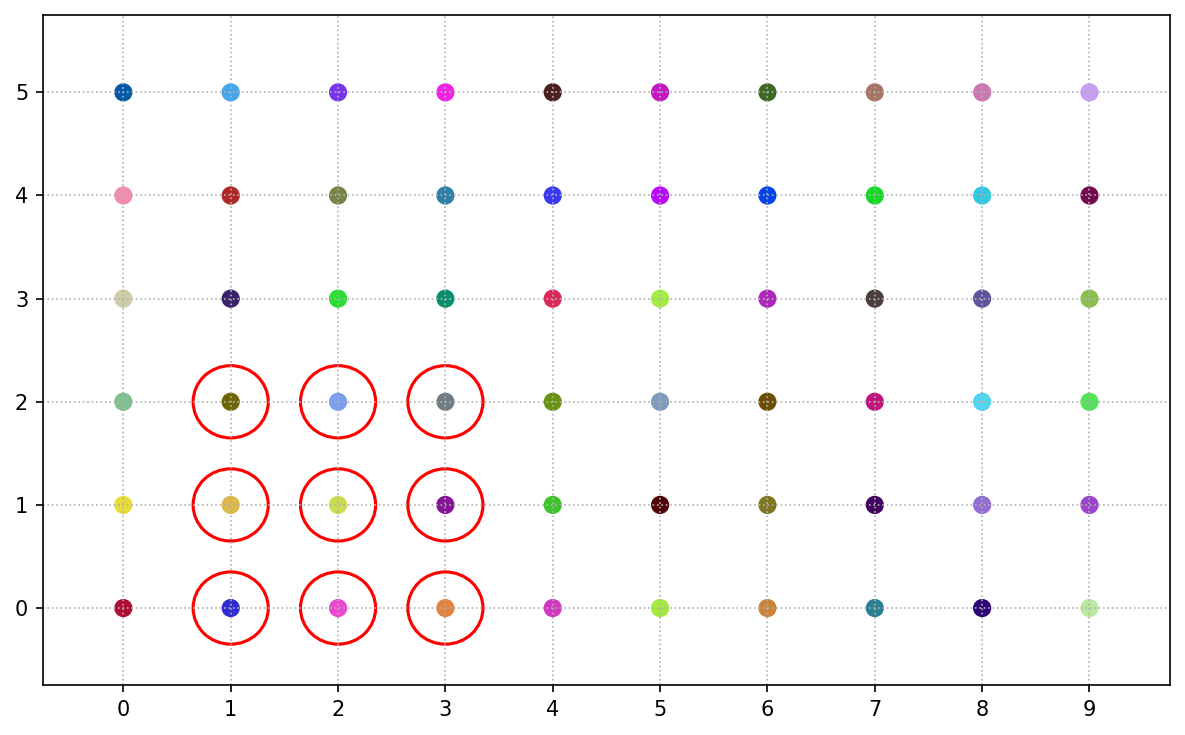

In [72]:
# convenience sampling
def convenience_sampling(xs, ys, colors, rows, cols, center=(5, 5), radius=2):
    cx, cy = center
    idx = np.where((np.abs(xs - cx) <= radius) & (np.abs(ys - cy) <= radius))[0]
    plot_sampling(xs, ys, colors, idx, rows, cols, "convenience_sampling.webp")

convenience_sampling(xs, ys, colors, rows, cols, center=(2, 1), radius=1)

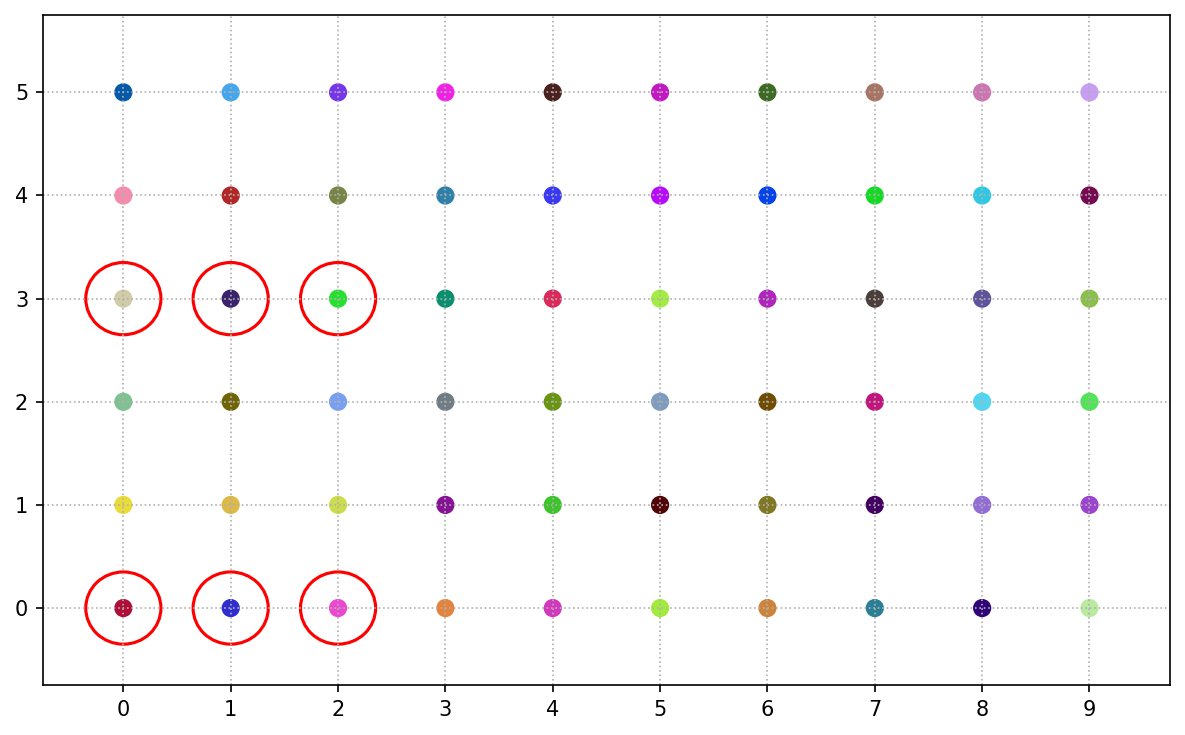

In [73]:
# judgment sampling
def judgment_sampling(xs, ys, colors, rows, cols):
    idx = []
    idx.extend(np.where(ys == 0)[0][:3])
    idx.extend(np.where(ys == rows//2)[0][:3])
    plot_sampling(xs, ys, colors, idx, rows, cols, "judgment_sampling.webp")

judgment_sampling(xs, ys, colors, rows, cols)

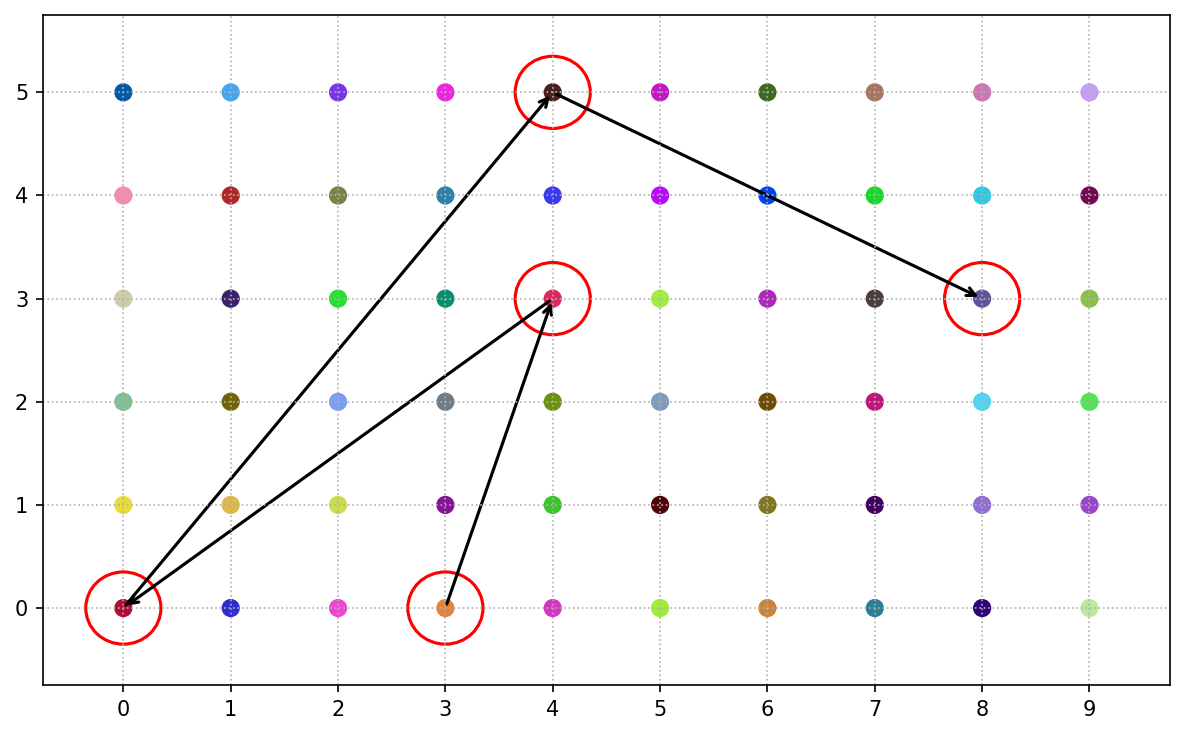

In [74]:
# snowball sampling
def snowball_sampling(xs, ys, colors, rows, cols, n_samples=5, seed=None):
    rng = np.random.default_rng(seed)
    selected_idx = rng.choice(len(xs), size=n_samples, replace=False)
    arrows = [(selected_idx[i], selected_idx[i+1]) for i in range(len(selected_idx)-1)]
    plot_sampling(xs, ys, colors, selected_idx, rows, cols, "snowball_sampling.webp", arrows=arrows)

snowball_sampling(xs, ys, colors, rows, cols, seed=seed)

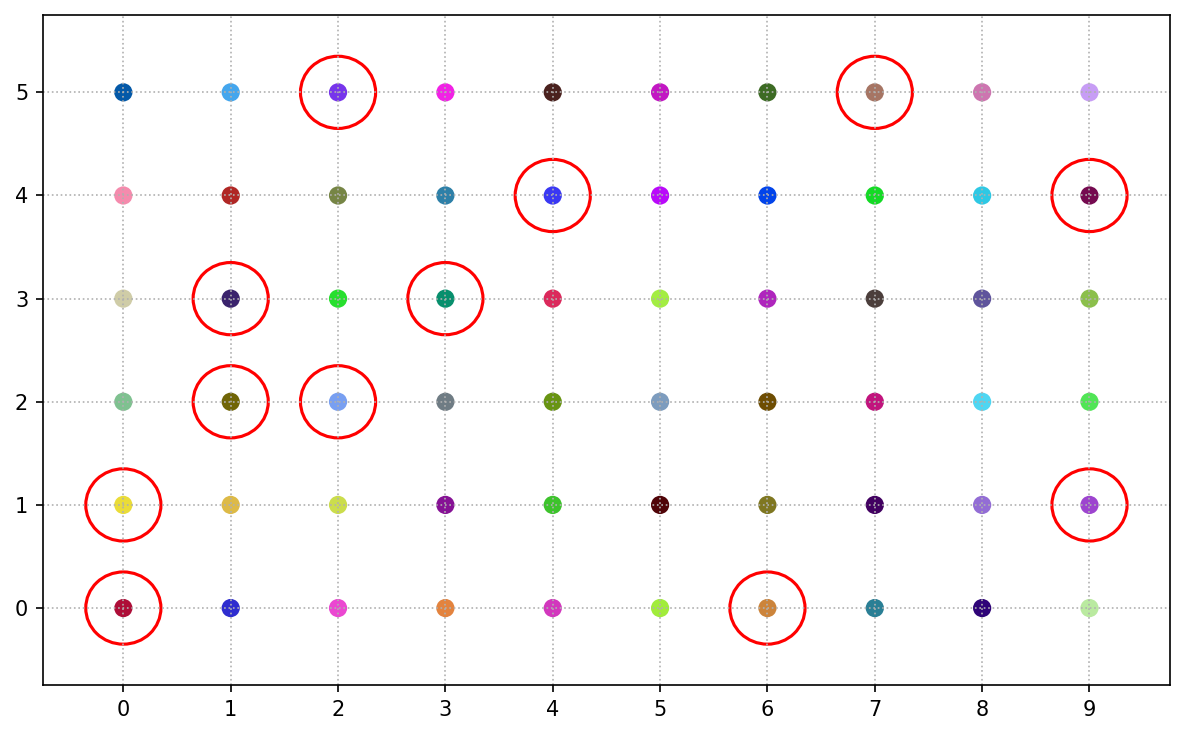

In [75]:
# quota sampling
def quota_sampling(xs, ys, colors, rows, cols, quota_per_row=2, seed=None):
    rng = np.random.default_rng(seed)
    idx = []
    for row in range(rows):
        idx_row = np.where(ys == row)[0]
        chosen = rng.choice(idx_row, size=min(quota_per_row, len(idx_row)), replace=False)
        idx.extend(chosen)
    plot_sampling(xs, ys, colors, idx, rows, cols, "quota_sampling.webp")

quota_sampling(xs, ys, colors, rows, cols, quota_per_row=2, seed=seed)